# FitRank: Analysis Notebook

EDA, baseline comparison, and evaluation of the fine-tuned cross-encoder.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_colwidth', 60)

train = pd.read_csv('data/train_pairs.csv')
eval_blind = pd.read_csv('data/eval_pairs_blind.csv')
labeled = pd.read_csv('data/labeled_eval_fixed.csv')
scored = pd.read_csv('data/eval_scored_comparison.csv')

eval_df = eval_blind.drop(columns=['human_label']).merge(
    labeled[['resume_id', 'job_id', 'human_label']], on=['resume_id', 'job_id']
)
print(train.shape, eval_df.shape, scored.shape)


(6729, 6) (168, 7) (168, 10)


## 1. Category distribution

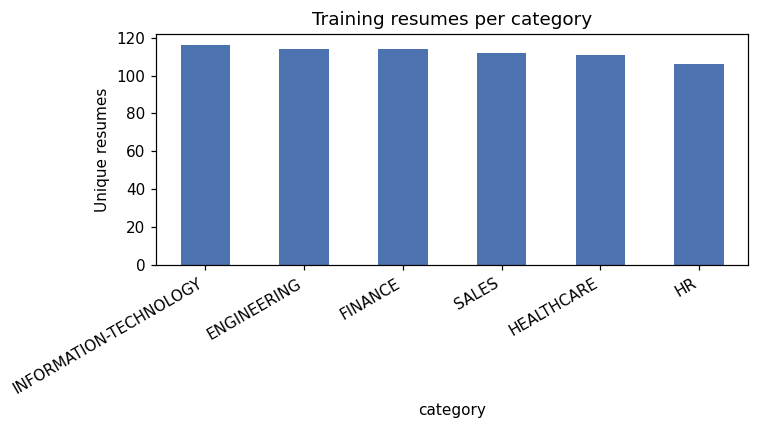

In [2]:
cat_counts = train.groupby('category')['resume_id'].nunique().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7, 4))
cat_counts.plot(kind='bar', ax=ax, color='#4C72B0')
ax.set_ylabel('Unique resumes')
ax.set_title('Training resumes per category')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


## 2. Text length distributions

Word counts for resume and job text, with the 250-word truncation threshold used at inference marked.

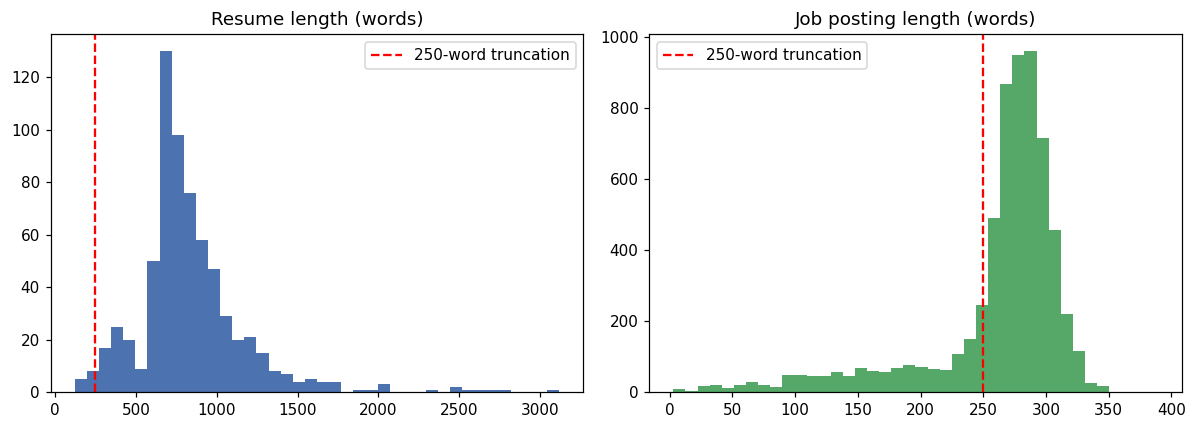

Resumes exceeding 250 words: 98.5%


In [3]:
resume_lens = train.drop_duplicates('resume_id')['resume_text'].str.split().str.len()
job_lens = train.drop_duplicates('job_id')['job_text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(resume_lens, bins=40, color='#4C72B0')
axes[0].axvline(250, color='red', linestyle='--', label='250-word truncation')
axes[0].set_title('Resume length (words)')
axes[0].legend()

axes[1].hist(job_lens, bins=40, color='#55A868')
axes[1].axvline(250, color='red', linestyle='--', label='250-word truncation')
axes[1].set_title('Job posting length (words)')
axes[1].legend()
plt.tight_layout()
plt.show()

pct_truncated = (resume_lens > 250).mean()
print(f"Resumes exceeding 250 words: {pct_truncated:.1%}")


## 3. Job pool composition per category

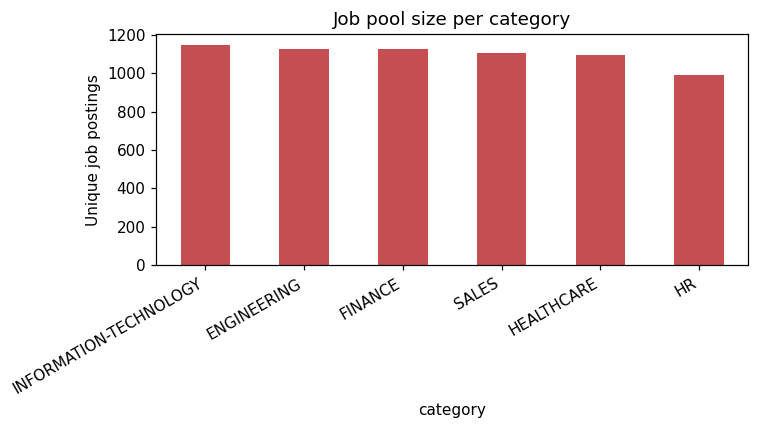

In [4]:
pool_counts = train.groupby('category')['job_id'].nunique().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7, 4))
pool_counts.plot(kind='bar', ax=ax, color='#C44E52')
ax.set_ylabel('Unique job postings')
ax.set_title('Job pool size per category')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


## 4. Heuristic label vs. human label agreement

Comparing the weak-supervision heuristic label (used for training) against the independently hand-labeled eval set. The heuristic label is not stored as a column in the shared eval files, so the confusion matrix below is reported directly from the earlier hand-labeling pass.

In [5]:
# confusion matrix from the heuristic-vs-human labeling pass on the 168 blind eval pairs
conf_matrix = pd.DataFrame(
    [[87, 8], [44, 29]],
    index=pd.Index(['heuristic=0', 'heuristic=1'], name='heuristic'),
    columns=pd.Index(['human=0', 'human=1'], name='human'),
)
agreement = (conf_matrix.loc['heuristic=0', 'human=0'] + conf_matrix.loc['heuristic=1', 'human=1']) / conf_matrix.values.sum()
heuristic_precision = conf_matrix.loc['heuristic=1', 'human=1'] / conf_matrix.loc['heuristic=1'].sum()

print(f"Agreement rate: {agreement:.1%}")
print(f"Heuristic precision (of heuristic=1, how many are actually relevant): {heuristic_precision:.1%}")
conf_matrix


Agreement rate: 69.0%
Heuristic precision (of heuristic=1, how many are actually relevant): 39.7%


human,human=0,human=1
heuristic,,
heuristic=0,87,8
heuristic=1,44,29


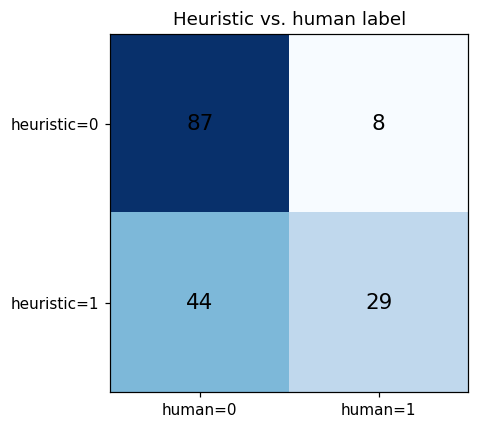

In [6]:
fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(conf_matrix.values, cmap='Blues')
ax.set_xticks([0, 1])
ax.set_xticklabels(['human=0', 'human=1'])
ax.set_yticks([0, 1])
ax.set_yticklabels(['heuristic=0', 'heuristic=1'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, conf_matrix.values[i, j], ha='center', va='center', fontsize=14)
ax.set_title('Heuristic vs. human label')
plt.tight_layout()
plt.show()


The weak-supervision heuristic only holds up ~40% of the time when it calls a pair relevant. This gap is the core motivation for fine-tuning on richer signal instead of relying on the heuristic directly.

In [7]:
overall_relevant_rate = labeled['human_label'].mean()
print(f"Overall human-labeled relevant rate: {overall_relevant_rate:.1%} ({labeled['human_label'].sum()}/{len(labeled)})")


Overall human-labeled relevant rate: 22.0% (37/168)


## 5. Category-wise human-labeled relevant rate

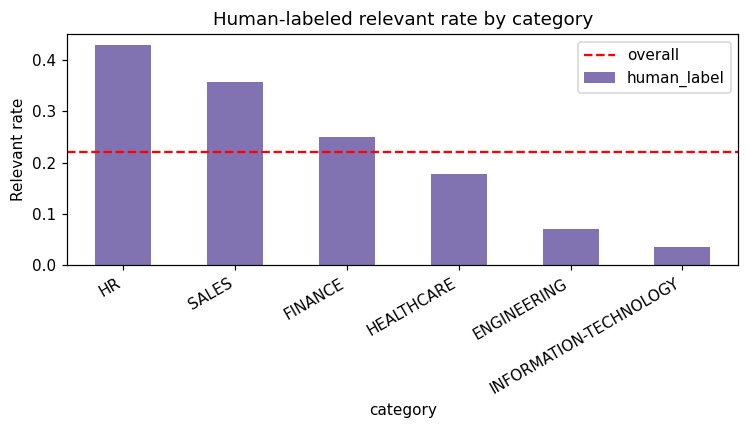

category
HR                        0.428571
SALES                     0.357143
FINANCE                   0.250000
HEALTHCARE                0.178571
ENGINEERING               0.071429
INFORMATION-TECHNOLOGY    0.035714
Name: human_label, dtype: float64


In [8]:
cat_rate = labeled.groupby('category')['human_label'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7, 4))
cat_rate.plot(kind='bar', ax=ax, color='#8172B2')
ax.set_ylabel('Relevant rate')
ax.set_title('Human-labeled relevant rate by category')
ax.axhline(overall_relevant_rate, color='red', linestyle='--', label='overall')
plt.xticks(rotation=30, ha='right')
plt.legend()
plt.tight_layout()
plt.show()
print(cat_rate)


## 6. Metric functions

AUC-ROC over all pairs, and Precision@1 per resume (only over resumes with at least one relevant candidate).

In [9]:
def precision_at_1(df, score_col, label_col='human_label'):
    correct, total = 0, 0
    for rid, grp in df.groupby('resume_id'):
        if grp[label_col].sum() == 0:
            continue
        top = grp.loc[grp[score_col].idxmax()]
        correct += int(top[label_col] == 1)
        total += 1
    return correct / total, correct, total


## 7. Tier A: TF-IDF + cosine similarity

In [10]:
tfidf = TfidfVectorizer(max_features=20000, stop_words='english')
tfidf.fit(pd.concat([train['resume_text'], train['job_text']]))

resume_vecs = tfidf.transform(eval_df['resume_text'])
job_vecs = tfidf.transform(eval_df['job_text'])
tfidf_scores = np.array([cosine_similarity(resume_vecs[i], job_vecs[i])[0, 0] for i in range(len(eval_df))])

eval_df['tfidf_score'] = tfidf_scores
tfidf_auc = roc_auc_score(eval_df['human_label'], tfidf_scores)
tfidf_p1, tfidf_correct, tfidf_total = precision_at_1(eval_df, 'tfidf_score')
print(f"TF-IDF  AUC-ROC: {tfidf_auc:.3f}   P@1: {tfidf_p1:.3f} ({tfidf_correct}/{tfidf_total})")


TF-IDF  AUC-ROC: 0.824   P@1: 0.667 (12/18)


## 8. Tier B: pretrained bi-encoder (all-MiniLM-L6-v2)

Computed separately against the actual model (`bi_encoder_baseline.py`). Reported here directly.

In [11]:
bi_auc, bi_p1 = 0.772, 0.722  # from bi_encoder_baseline.py, local run

print(f"Bi-encoder  AUC-ROC: {bi_auc:.3f}   P@1: {bi_p1:.3f}")


Bi-encoder  AUC-ROC: 0.772   P@1: 0.722


## 9. Tier C & D: pretrained cross-encoder vs. fine-tuned cross-encoder

Computed separately (`compare_models.py`, local GPU/CPU run against the actual model weights). Reported here directly.

In [12]:
ce_baseline_auc, ce_baseline_p1 = 0.739, 0.611
ce_finetuned_auc, ce_finetuned_p1 = 0.871, 0.778

print(f"Cross-encoder (pretrained)  AUC-ROC: {ce_baseline_auc:.3f}   P@1: {ce_baseline_p1:.3f} (11/18)")
print(f"Cross-encoder (fine-tuned)  AUC-ROC: {ce_finetuned_auc:.3f}   P@1: {ce_finetuned_p1:.3f} (14/18)")


Cross-encoder (pretrained)  AUC-ROC: 0.739   P@1: 0.611 (11/18)
Cross-encoder (fine-tuned)  AUC-ROC: 0.871   P@1: 0.778 (14/18)


## 10. Four-tier comparison

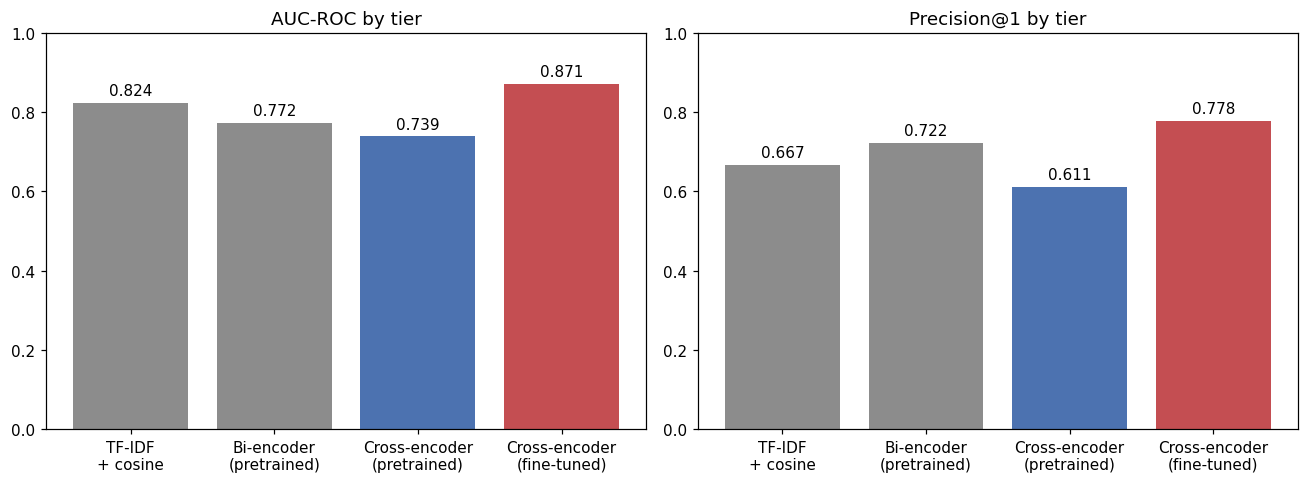

,tier,auc_roc,precision_at_1
0,TF-IDF\n+ cosine,0.824015,0.666667
1,Bi-encoder\n(pretrained),0.772000,0.722000
2,Cross-encoder\n(pretrained),0.739000,0.611000
3,Cross-encoder\n(fine-tuned),0.871000,0.778000


In [13]:
tiers = ['TF-IDF\n+ cosine', 'Bi-encoder\n(pretrained)', 'Cross-encoder\n(pretrained)', 'Cross-encoder\n(fine-tuned)']
auc_vals = [tfidf_auc, bi_auc, ce_baseline_auc, ce_finetuned_auc]
p1_vals = [tfidf_p1, bi_p1, ce_baseline_p1, ce_finetuned_p1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
colors = ['#8C8C8C', '#8C8C8C', '#4C72B0', '#C44E52']

axes[0].bar(tiers, auc_vals, color=colors)
axes[0].set_ylim(0, 1)
axes[0].set_title('AUC-ROC by tier')
for i, v in enumerate(auc_vals):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center')

axes[1].bar(tiers, p1_vals, color=colors)
axes[1].set_ylim(0, 1)
axes[1].set_title('Precision@1 by tier')
for i, v in enumerate(p1_vals):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center')

plt.tight_layout()
plt.show()

summary = pd.DataFrame({
    'tier': tiers,
    'auc_roc': auc_vals,
    'precision_at_1': p1_vals,
})
summary


## 11. Bootstrap confidence intervals

Resume-level bootstrap (resampling the 18 eligible resumes with replacement, 2000 iterations) for the pretrained and fine-tuned cross-encoder, using the actual per-pair scores from `compare_models.py`.

In [14]:
rng = np.random.default_rng(42)

scored_eligible_resumes = [rid for rid, grp in scored.groupby('resume_id') if grp['human_label'].sum() > 0]
scored_by_resume = {rid: grp for rid, grp in scored.groupby('resume_id')}

def bootstrap_auc_p1(score_col, n_iter=2000):
    aucs, p1s = [], []
    all_resumes = scored['resume_id'].unique()
    for _ in range(n_iter):
        sample_ids = rng.choice(all_resumes, size=len(all_resumes), replace=True)
        sample_df = pd.concat([scored_by_resume[rid] for rid in sample_ids], ignore_index=True)
        if sample_df['human_label'].nunique() < 2:
            continue
        aucs.append(roc_auc_score(sample_df['human_label'], sample_df[score_col]))
        p1, _, total = precision_at_1(sample_df, score_col)
        if total > 0:
            p1s.append(p1)
    return np.array(aucs), np.array(p1s)

baseline_aucs, baseline_p1s = bootstrap_auc_p1('baseline_score')
finetuned_aucs, finetuned_p1s = bootstrap_auc_p1('finetuned_score')

def ci(arr, lo=2.5, hi=97.5):
    return np.percentile(arr, lo), np.percentile(arr, hi)

print("Baseline  AUC 95% CI:", tuple(round(x, 3) for x in ci(baseline_aucs)))
print("Finetuned AUC 95% CI:", tuple(round(x, 3) for x in ci(finetuned_aucs)))
print("Baseline  P@1 95% CI:", tuple(round(x, 3) for x in ci(baseline_p1s)))
print("Finetuned P@1 95% CI:", tuple(round(x, 3) for x in ci(finetuned_p1s)))


Baseline  AUC 95% CI: (np.float64(0.642), np.float64(0.839))
Finetuned AUC 95% CI: (np.float64(0.789), np.float64(0.94))
Baseline  P@1 95% CI: (np.float64(0.444), np.float64(0.8))
Finetuned P@1 95% CI: (np.float64(0.636), np.float64(0.917))


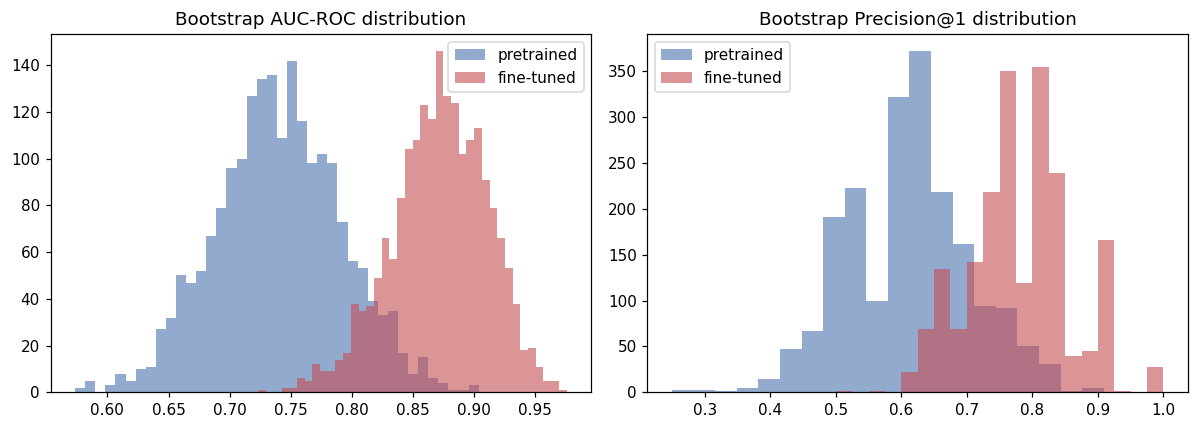

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(baseline_aucs, bins=40, alpha=0.6, label='pretrained', color='#4C72B0')
axes[0].hist(finetuned_aucs, bins=40, alpha=0.6, label='fine-tuned', color='#C44E52')
axes[0].set_title('Bootstrap AUC-ROC distribution')
axes[0].legend()

axes[1].hist(baseline_p1s, bins=20, alpha=0.6, label='pretrained', color='#4C72B0')
axes[1].hist(finetuned_p1s, bins=20, alpha=0.6, label='fine-tuned', color='#C44E52')
axes[1].set_title('Bootstrap Precision@1 distribution')
axes[1].legend()

plt.tight_layout()
plt.show()


These intervals are wide because they rest on 18 resumes. The point estimates favor the fine-tuned model consistently, but this is directional signal rather than a tight statistical claim.

## 12. Error analysis: which pairs flipped after fine-tuning

For each resume, compare whether the pretrained vs. fine-tuned model's top-ranked candidate was correct.

In [16]:
def top_pick(grp, score_col):
    return grp.loc[grp[score_col].idxmax()]

flips = []
for rid, grp in scored.groupby('resume_id'):
    if grp['human_label'].sum() == 0:
        continue
    base_top = top_pick(grp, 'baseline_score')
    ft_top = top_pick(grp, 'finetuned_score')
    base_correct = int(base_top['human_label'] == 1)
    ft_correct = int(ft_top['human_label'] == 1)
    flips.append({
        'resume_id': rid,
        'category': grp['category'].iloc[0],
        'baseline_correct': base_correct,
        'finetuned_correct': ft_correct,
        'baseline_top_job': base_top['job_title'],
        'finetuned_top_job': ft_top['job_title'],
    })

flips_df = pd.DataFrame(flips)
flips_df['flip'] = np.select(
    [
        (flips_df.baseline_correct == 0) & (flips_df.finetuned_correct == 1),
        (flips_df.baseline_correct == 1) & (flips_df.finetuned_correct == 0),
    ],
    ['wrong_to_right', 'right_to_wrong'],
    default='unchanged'
)
flips_df['flip'].value_counts()


flip
wrong_to_right    7
unchanged         7
right_to_wrong    4
Name: count, dtype: int64

In [17]:
wrong_to_right = flips_df[flips_df['flip'] == 'wrong_to_right']
right_to_wrong = flips_df[flips_df['flip'] == 'right_to_wrong']

print(f"Wrong -> Right after fine-tuning: {len(wrong_to_right)} resumes")
print(f"Right -> Wrong after fine-tuning: {len(right_to_wrong)} resumes")
wrong_to_right[['resume_id', 'category', 'baseline_top_job', 'finetuned_top_job']]


Wrong -> Right after fine-tuning: 7 resumes
Right -> Wrong after fine-tuning: 4 resumes


,resume_id,category,baseline_top_job,finetuned_top_job
0,12858898,FINANCE,Employee Benefits Specialist,Project Financial Analyst
5,23296286,SALES,Area Operations Coordinator,Sales Executive
7,26958533,HEALTHCARE,Brake Press Operator - 2nd shift,Sales Engineer
8,28198029,SALES,Lead Strategic Sales Planning Manager,Associate Sales Representative / Clinical Support
9,29149998,HR,"Head, Talent Acquisition –CCO, CPO, SSGA & Global Market...",Associate HR Business Partner (Temporary)
11,31677347,ENGINEERING,Internal Communications Senior Manager,"Front-End Engineer II, AWS Marketplace, Product Types"
14,47410104,FINANCE,AVP Underwriter,Sr. FP&A Analyst


In [18]:
right_to_wrong[['resume_id', 'category', 'baseline_top_job', 'finetuned_top_job']]


,resume_id,category,baseline_top_job,finetuned_top_job
3,20237244,INFORMATION-TECHNOLOGY,Security Training Supervisor $21.50/hr,Full Stack Software Engineer
10,30083943,SALES,Sales Manager,Pro Territory Sales Manager
16,85417107,HEALTHCARE,Title Processing Clerk,"Registered Nurse, Home Health Full Time"
17,93988900,HEALTHCARE,"Certified Medical Assistant (CCMA), Day Shift, Germantow...",Nurse Practitioner


## Summary

Fine-tuning moved the model's top-1 pick from wrong to right for more resumes than it broke, consistent with the aggregate Precision@1 improvement (11/18 to 14/18). The gains concentrate in cases where the pretrained model's top pick was topically close but not the actual relevant posting.

## 13. Ablation: training set size

Same hyperparameters (3 epochs, batch size 16, lr 2e-5, warmup 0.1) fine-tuned on increasing subsets of the training pool, each evaluated against the same 168-pair eval set. Subsets are stratified by label to preserve the class ratio.

In [19]:
ablation = pd.read_csv('data/ablation_results.csv').sort_values('train_size').reset_index(drop=True)
ablation


,train_size,auc_roc,precision_at_1
0,500,0.777801,0.722222
1,1000,0.813183,0.777778
2,2000,0.852796,0.833333
3,4000,0.855787,0.777778
4,6729,0.871000,0.778000


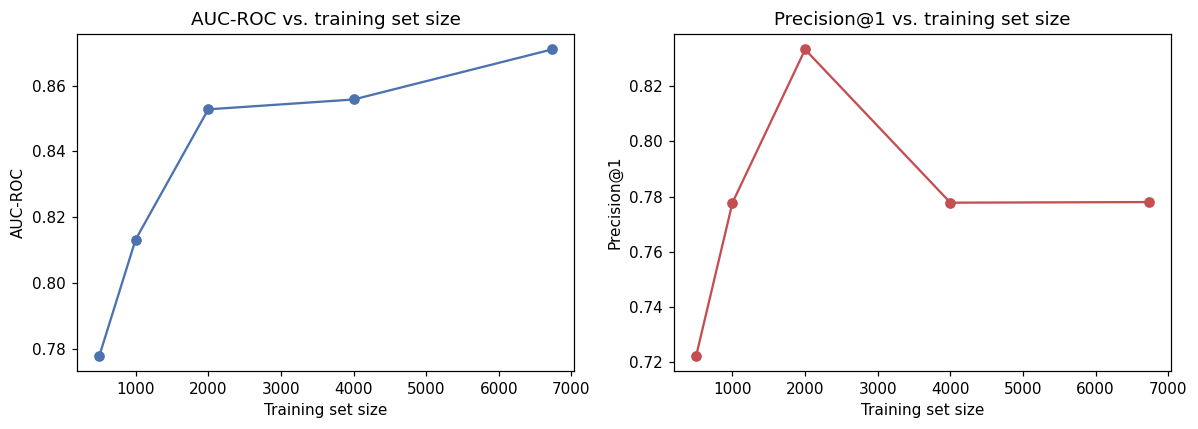

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(ablation['train_size'], ablation['auc_roc'], marker='o', color='#4C72B0')
axes[0].set_xlabel('Training set size')
axes[0].set_ylabel('AUC-ROC')
axes[0].set_title('AUC-ROC vs. training set size')

axes[1].plot(ablation['train_size'], ablation['precision_at_1'], marker='o', color='#C44E52')
axes[1].set_xlabel('Training set size')
axes[1].set_ylabel('Precision@1')
axes[1].set_title('Precision@1 vs. training set size')

plt.tight_layout()
plt.show()


AUC-ROC improves sharply from 500 to 2,000 pairs (+0.075) and then flattens out (2,000 to 6,729 pairs gains only +0.018). Precision@1 is noisier at this eval set size (18 eligible resumes means each point moves in 1/18 increments), so AUC-ROC is the more reliable signal here. The practical takeaway: most of the benefit of fine-tuning on this task is captured well before the full training pool is used, which matters if labeling more pairs has a real cost.